### Chronic Wasting Disease (CWD) – Exploratory Data Analysis
**Wild and Captive Positive Cervid Cases in the United States**

**Author:** Maria Julia Judson

This notebook uses publicly available USGS data to analyze the distribution of CWD across U.S. states
and prepares a cleaned dataset for visualization in Power BI.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('20250408_CWD_Wild.csv')

df.head()


,State,County
0,Alabama,Colbert
1,Alabama,Lauderdale
2,Arkansas,Baxter
3,Arkansas,Benton
4,Arkansas,Boone


This dataset indicates CWD positiveness in wild, free-ranging cervid populations per county, per State [(DATA OF APRIL, 2025)](https://www.sciencebase.gov/catalog/item/58068050e4b0824b2d1d415d).

In [ ]:
df.columns

Index(['state', 'county'], dtype='object')

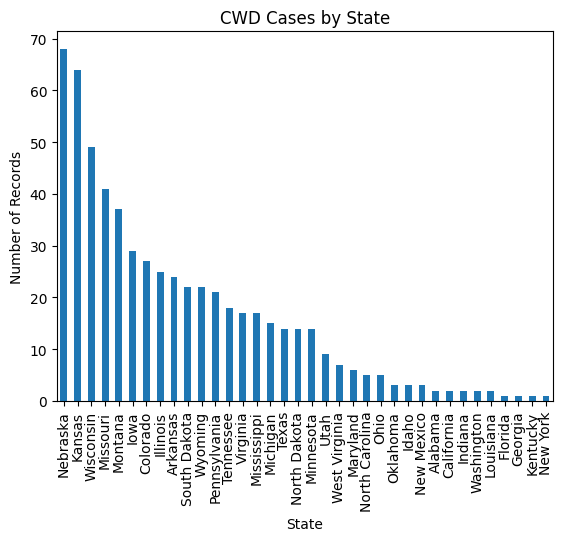

In [ ]:
cases_per_state = df['state'].value_counts()

cases_per_state.plot(kind='bar')
plt.title("CWD Cases by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.show()


Out of 36 U.S. States, CWD has the highest positivety rates in wild cervid populations in the state of Nebraska and the lowest rates in the state of New York [(DATA OF APRIL, 2025)](https://www.sciencebase.gov/catalog/item/58068050e4b0824b2d1d415d).

In [ ]:
top_counties = df.groupby(['county', 'state']).size().sort_values(ascending=False).head(10)

top_counties


,,0
county,state,
Ziebach,South Dakota,1
Williams,North Dakota,1
Will,Illinois,1
Wilkes,North Carolina,1
Wichita,Kansas,1
Weston,Wyoming,1
Westmoreland,Pennsylvania,1
Weld,Colorado,1
Webster,Nebraska,1


In [ ]:
print("Number of states affected:", df['state'].nunique())
print("Total records:", len(df))


Number of states affected: 36
Total records: 593


The dataset shows that CWD is present in wild cervid populations in 36 states. Some states show broader geographic spread (more counties affected) than others.

In [ ]:
# make everything lowercase (avoid duplicates like "Texas" vs "texas")
df['state'] = df['state'].str.lower()
df['county'] = df['county'].str.lower()

# remove spaces
df['state'] = df['state'].str.strip()
df['county'] = df['county'].str.strip()

df.head()


,state,county
0,alabama,colbert
1,alabama,lauderdale
2,arkansas,baxter
3,arkansas,benton
4,arkansas,boone


In [ ]:
df = df.drop_duplicates()

print("Total unique records:", len(df))


Total unique records: 593


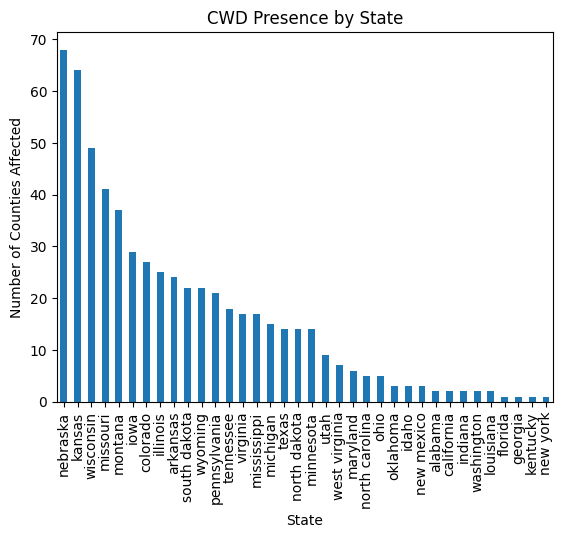

In [ ]:
cases_per_state = df['state'].value_counts()

cases_per_state.plot(kind='bar')
plt.title("CWD Presence by State")
plt.xlabel("State")
plt.ylabel("Number of Counties Affected")
plt.show()


The graph showcases CWD positiveness in wild cervid populations in 36 U.S. States, plus number of counties affected by the disease [(DATA OF APRIL, 2025)](https://www.sciencebase.gov/catalog/item/58068050e4b0824b2d1d415d).

In [ ]:
top_counties = df.groupby(['state', 'county']).size().reset_index(name='count')

top_counties.head(10)


,state,county,count
0,alabama,colbert,1
1,alabama,lauderdale,1
2,arkansas,baxter,1
3,arkansas,benton,1
4,arkansas,boone,1
5,arkansas,carroll,1
6,arkansas,cleburne,1
7,arkansas,conway,1
8,arkansas,craighead,1
9,arkansas,crawford,1


In [ ]:
print("Number of states affected:", df['state'].nunique())


Number of states affected: 36


In [ ]:
df.to_csv('cwd_clean_simple.csv', index=False)


In [ ]:
state_summary = df.groupby('state').size().reset_index(name='count')

state_summary = state_summary.sort_values(by='count', ascending=False)

state_summary.head()


,state,count
19,nebraska,68
10,kansas,64
34,wisconsin,49
17,missouri,41
18,montana,37


<Figure size 640x480 with 0 Axes>

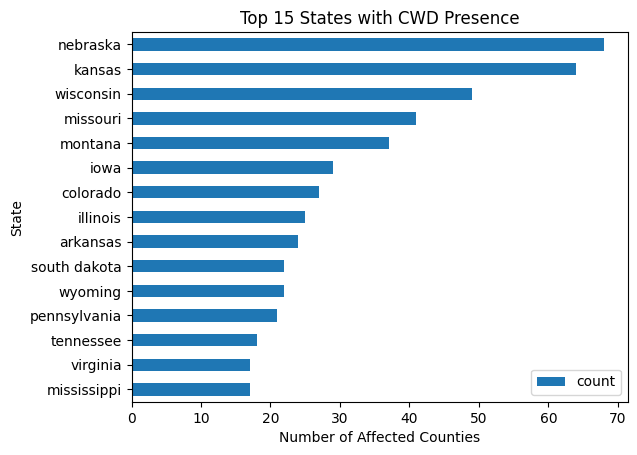

In [ ]:
plt.figure()
state_summary.head(15).plot(
    kind='barh',
    x='state',
    y='count'
)

plt.title("Top 15 States with CWD Presence")
plt.xlabel("Number of Affected Counties")
plt.ylabel("State")
plt.gca().invert_yaxis()

plt.show()


This graph highlights the top 15 States with CWD positiveness in wild cervid populations, including the number of affected counties [(DATA OF APRIL, 2025)](https://www.sciencebase.gov/catalog/item/58068050e4b0824b2d1d415d).

In [ ]:
!pip install geopandas


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('20250408_CWD_Wild.csv')

# clean again (important)
df.columns = df.columns.str.lower()
df['state'] = df['state'].str.lower().str.strip()
df['county'] = df['county'].str.lower().str.strip()

In [ ]:
usa_states = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

usa_states.head()


,id,name,density,geometry
0,01,Alabama,94.650,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847..."
1,02,Alaska,1.264,"MULTIPOLYGON (((-131.60202 55.11798, -131.5691..."
2,04,Arizona,57.050,"POLYGON ((-109.0425 37.00026, -109.04798 31.33..."
3,05,Arkansas,56.430,"POLYGON ((-94.47384 36.50186, -90.15254 36.496..."
4,06,California,241.700,"POLYGON ((-123.23326 42.00619, -122.37885 42.0..."


In [ ]:
state_counts = df['state'].value_counts().reset_index()
state_counts.columns = ['state', 'count']

# fix names (important)
state_counts['state'] = state_counts['state'].str.title()


In [ ]:
merged = usa_states.merge(
    state_counts,
    left_on='name',
    right_on='state',
    how='left'
)


In [ ]:
usa_states = gpd.read_file(
    "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
)


In [ ]:
usa_states = gpd.read_file(
    "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"
)


In [ ]:
usa_states = usa_states.set_geometry('geometry')


In [ ]:
merged = usa_states.merge(
    state_counts,
    left_on='name',
    right_on='state',
    how='left'
)


In [ ]:
import geopandas as gpd

usa_states = gpd.read_file('cb_2023_us_state_20m.shp')

usa_states.head()


,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,48,01779801,0400000US48,48,TX,Texas,00,676686238592,18982083586,"POLYGON ((-106.62344 31.91403, -106.63011 31.9..."
1,06,01779778,0400000US06,06,CA,California,00,403673296401,20291770234,"MULTIPOLYGON (((-118.59397 33.4672, -118.48478..."
2,21,01779786,0400000US21,21,KY,Kentucky,00,102266598312,2384223544,"POLYGON ((-89.54443 36.57451, -89.47935 36.566..."
3,13,01705317,0400000US13,13,GA,Georgia,00,149485311347,4419673221,"POLYGON ((-85.60516 34.98468, -85.47434 34.983..."
4,55,01779806,0400000US55,55,WI,Wisconsin,00,140292627460,29343084365,"MULTIPOLYGON (((-86.93428 45.42115, -86.83575 ..."


In [ ]:
usa_states['NAME'] = usa_states['NAME'].str.lower()


In [ ]:
state_counts = df['state'].value_counts().reset_index()
state_counts.columns = ['state', 'count']


In [ ]:
merged = usa_states.merge(
    state_counts,
    left_on='NAME',
    right_on='state',
    how='left'
)


In [ ]:
# filter out Alaska, Hawaii, and territories
exclude = ['alaska', 'hawaii', 'puerto rico']

merged = merged[~merged['NAME'].isin(exclude)]


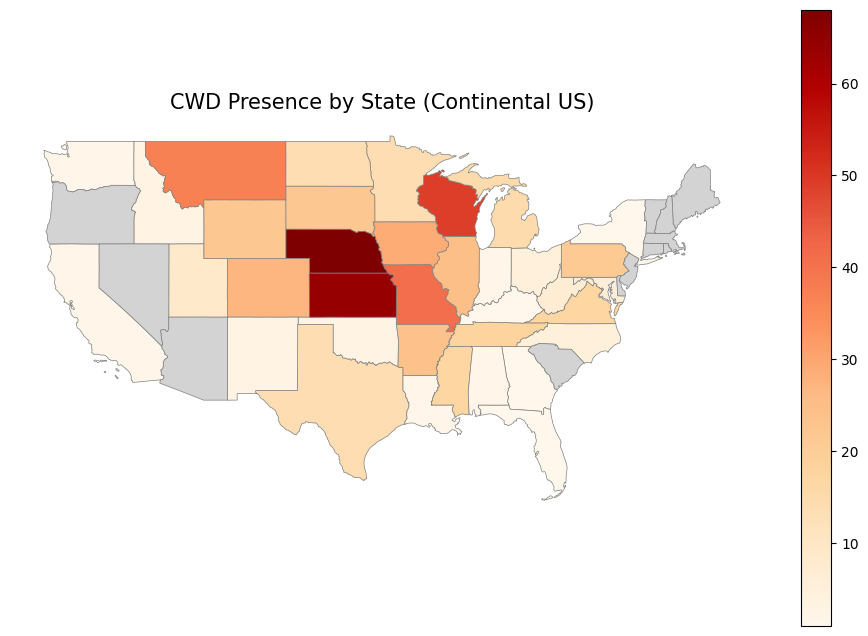

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

merged.plot(
    column='count',
    cmap='OrRd',
    linewidth=0.5,
    ax=ax,
    edgecolor='0.5',
    legend=True,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("CWD Presence by State (Continental US)", fontsize=15)
ax.axis('off')

plt.show()


This map shows CWD presence by State in wild cervid populations across the US.

In [ ]:
state_summary = df['state'].value_counts().reset_index()
state_summary.columns = ['state', 'count']

state_summary.to_csv('cwd_state_summary.csv', index=False)


# The following dataset indicates CWD positiveness in captive cervid populations per county, per State (DATA OF APRIL, 2025).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("20250408_CWD_Captive.csv")

df.head()

,State,County,Count
0,Colorado,Delta,2
1,Colorado,Eagle,2
2,Colorado,El Paso,1
3,Colorado,Fremont,1
4,Colorado,Garfield,1


In [ ]:
df.columns

Index(['State', 'County', 'Count'], dtype='object')

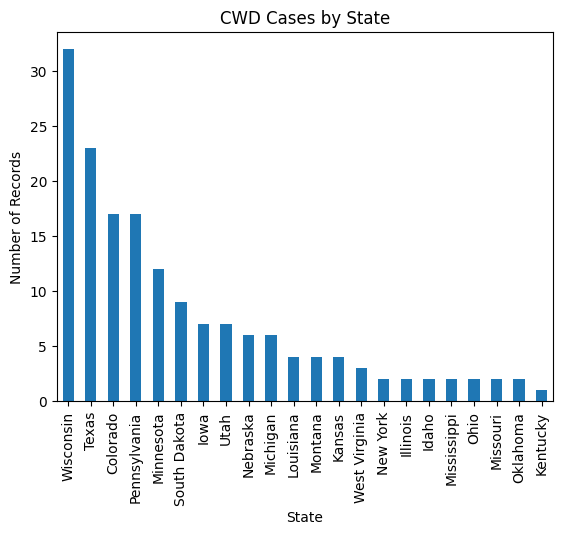

In [ ]:
cases_per_state = df['State'].value_counts()

cases_per_state.plot(kind='bar')
plt.title("CWD Cases by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.show()

Out of 22 U.S. states with CWD‑positive captive cervid populations, Wisconsin has the highest CWD positivity rate, while Kentucky has the lowest. [(DATA OF APRIL, 2025)](https://www.sciencebase.gov/catalog/item/58068050e4b0824b2d1d415d).

In [ ]:
top_counties = df.groupby(['County', 'State']).size().sort_values(ascending=False).head(10)

top_counties

,,0
County,State,
Adams,Pennsylvania,1
Aitkin,Minnesota,1
Allamakee,Iowa,1
Aurora,South Dakota,1
Bedford,Pennsylvania,1
Beltrami,Minnesota,1
Benton,Mississippi,1
Blair,Pennsylvania,1
Boone,Illinois,1


In [ ]:
print("Number of states affected:", df['State'].nunique())
print("Total records:", len(df))


Number of states affected: 22
Total records: 166


This data showcases the presence of CWD in captive cervid populations in 22 states.

In [ ]:
df = df.drop_duplicates()

print("Total unique records:", len(df))

Total unique records: 166


In [ ]:
top_counties = df.groupby(['State', 'County']).size().reset_index(name='count')

top_counties.head(10)

,State,County,count
0,Colorado,Delta,1
1,Colorado,Eagle,1
2,Colorado,El Paso,1
3,Colorado,Fremont,1
4,Colorado,Garfield,1
5,Colorado,Grand,1
6,Colorado,Jackson,1
7,Colorado,Jefferson,1
8,Colorado,Larimer,1
9,Colorado,Las Animas,1


In [ ]:
df.to_csv('cwd_clean_simple.csv', index=False)

In [ ]:
state_summary = df.groupby('State').size().reset_index(name='count')

state_summary = state_summary.sort_values(by='count', ascending=False)

state_summary.head()


,State,count
21,Wisconsin,32
18,Texas,23
0,Colorado,17
16,Pennsylvania,17
8,Minnesota,12


<Figure size 640x480 with 0 Axes>

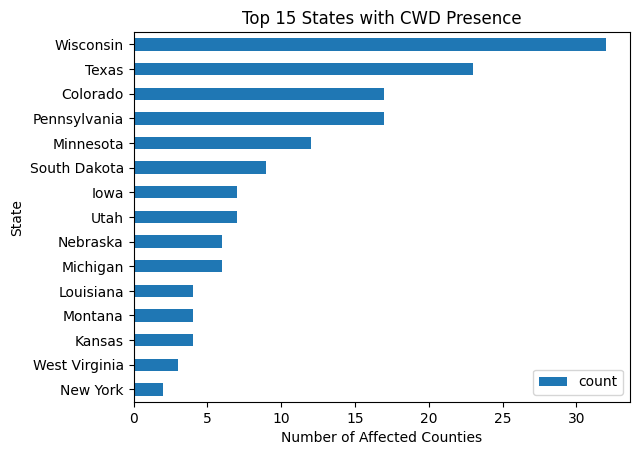

In [ ]:
plt.figure()
state_summary.head(15).plot(
    kind='barh',
    x='State',
    y='count'
)

plt.title("Top 15 States with CWD Presence")
plt.xlabel("Number of Affected Counties")
plt.ylabel("State")
plt.gca().invert_yaxis()

plt.show()

This graph highlights the top 15 States with CWD positiveness in captive cervid populations, including the number of affected counties (DATA OF APRIL, 2025). The state of Wisconsin has the highest rates, where New York has the lowest.

In [7]:
import pandas as pd

wild_df = pd.read_csv("20250408_CWD_Wild.csv")
captive_df = pd.read_csv("20250408_CWD_Captive.csv")

wild_df.columns = wild_df.columns.str.lower().str.strip()
captive_df.columns = captive_df.columns.str.lower().str.strip()

In [8]:
wild_summary = wild_df["state"].value_counts().reset_index()
wild_summary.columns = ["state", "wild_count"]

captive_summary = captive_df["state"].value_counts().reset_index()
captive_summary.columns = ["state", "captive_count"]

In [9]:
combined = pd.merge(wild_summary, captive_summary, on="state", how="outer").fillna(0)

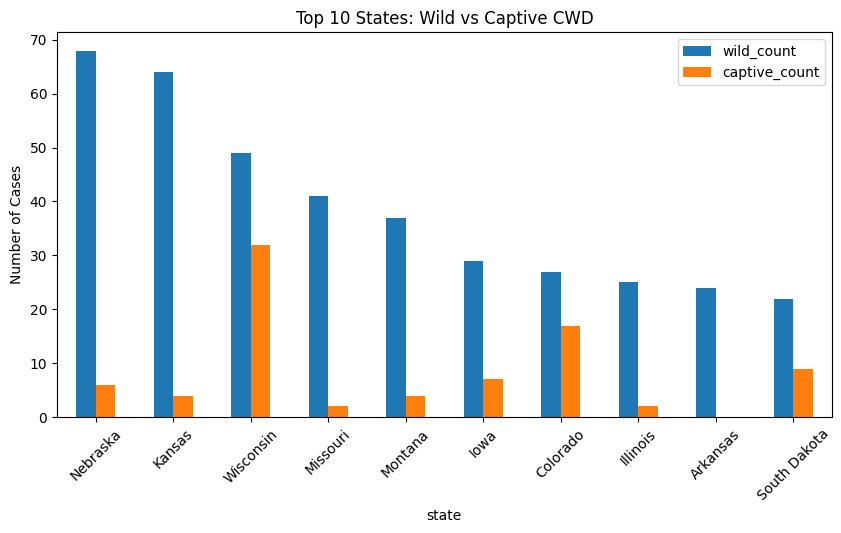

In [10]:
import matplotlib.pyplot as plt

combined.set_index("state")[["wild_count", "captive_count"]] \
    .sort_values(by="wild_count", ascending=False) \
    .head(10) \
    .plot(kind="bar", figsize=(10,5))

plt.title("Top 10 States: Wild vs Captive CWD")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)

plt.savefig("wild_vs_captive.png", bbox_inches='tight')
plt.show()

In this graph we can visualize the difference among the top 10 CWD‑positive U.S. States regarding wild and captive cervid populations. The comparison shows that wild CWD cases significantly exceed captive cases across most states, indicating broader environmental transmission and spread among free-ranging populations. (April 2025 data).